# CatBoost Regressor - Regression Problem

CatBoost is a gradient boosting algorithm that handles categorical features efficiently.
It is particularly useful for regression problems where the target is continuous.

**Applications:**
- Predicting house prices
- Medical outcomes (like diabetes progression)
- Financial forecasting
- Demand prediction

**Why use CatBoost?**
- Handles categorical features natively
- Reduces overfitting with Ordered Boosting
- High accuracy with minimal parameter tuning
- Efficient GPU training support

**Importing Libraries**

In [4]:
import pandas as pd            # Data manipulation
import numpy as np             # Numerical operations
import matplotlib.pyplot as plt # Visualization
import seaborn as sns           # Advanced visualization

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from catboost import CatBoostRegressor, Pool

import shap                      # Model explainability
import joblib                    # Model saving

sns.set(style="whitegrid")

**Load dataset**

In [5]:
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target, name="target")

In [6]:
print("Dataset shape:", X.shape)

Dataset shape: (442, 10)


In [7]:
display(X.head())

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [8]:
print("\nTarget shape:", y.shape)


Target shape: (442,)


In [9]:
print("\nDataset description:\n", diabetes.DESCR)


Dataset description:
 .. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 fea

**Exploratory Data Analysis (EDA)**

In [10]:
print("Data types:\n", X.dtypes)

Data types:
 age    float64
sex    float64
bmi    float64
bp     float64
s1     float64
s2     float64
s3     float64
s4     float64
s5     float64
s6     float64
dtype: object


In [11]:
print("\nMissing values:\n", X.isnull().sum())


Missing values:
 age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64


In [12]:
print("\nStatistical summary:\n", X.describe())


Statistical summary:
                 age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.123988e-01 -1.267807e-01   
25%   -3.729927e-02 -4.464164e-02 -3.422907e-02 -3.665608e-02 -3.424784e-02   
50%    5.383060e-03 -4.464164e-02 -7.283766e-03 -5.670422e-03 -4.320866e-03   
75%    3.807591e-02  5.068012e-02  3.124802e-02  3.564379e-02  2.835801e-02   
max    1.107267e-01  5.068012e-02  1.705552e-01  1.320436e-01  1.539137e-01   

                 s2            s3            s4            s5            s6  
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  
mean   3.918434e-17 -5.777179e-18 -9.042540e-18  9.293722e-17  1.130318e-17  
std    4.761905e-02  4.761905e-

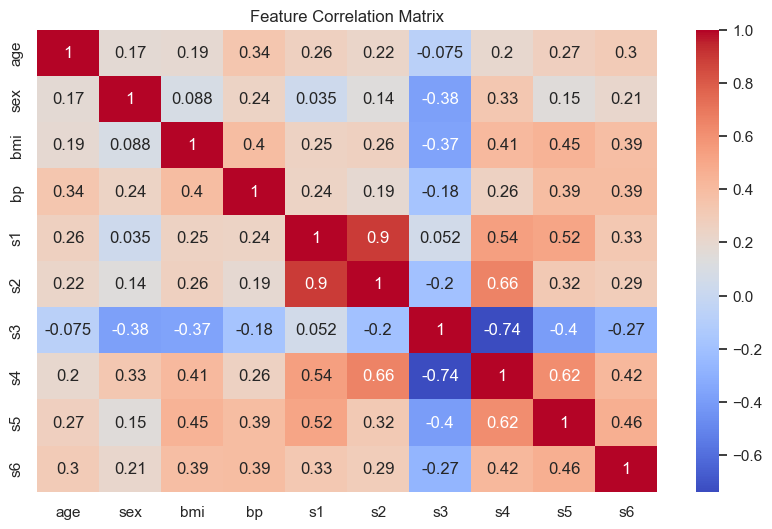

In [13]:
# Correlation Matrix
plt.figure(figsize=(10,6))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

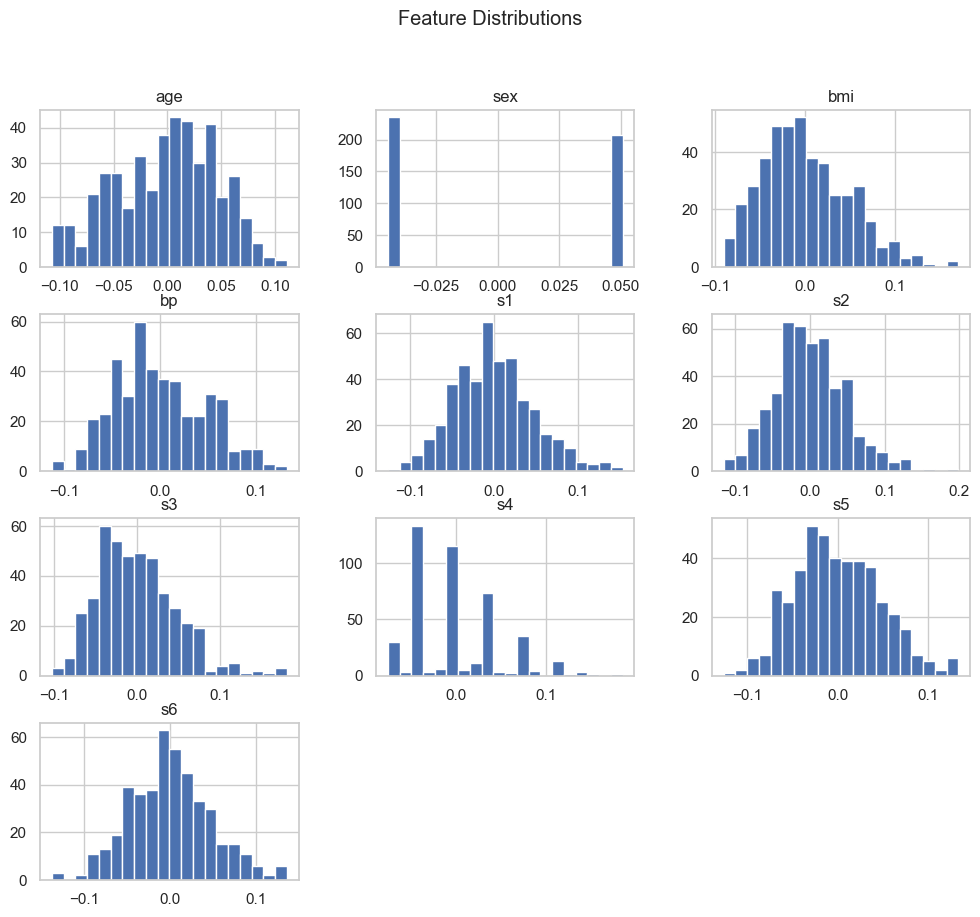

In [15]:
# Distribution plots
X.hist(figsize=(12,10), bins=20)
plt.suptitle("Feature Distributions")
plt.show()

**Data Preprocessing**

In [17]:
# No missing values in this dataset, but we scale features for gradient boosting
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Feature Engineering**

In [18]:
# For demonstration, we'll create an interaction feature
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df['bmi_age_interaction'] = X_scaled_df['bmi'] * X_scaled_df['age']

**Train-Test Split**

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y, test_size=0.2, random_state=42
)

In [20]:
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (353, 11)
Test set shape: (89, 11)


**Machine Learning Pipeline**

In [21]:
pipeline = Pipeline([
    ("model", CatBoostRegressor(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        eval_metric='RMSE',
        verbose=100,
        random_seed=42
    ))
])

**Model Training**

In [22]:
pipeline.fit(X_train, y_train)

0:	learn: 76.5966969	total: 157ms	remaining: 2m 36s
100:	learn: 40.6246578	total: 314ms	remaining: 2.79s
200:	learn: 32.2215056	total: 448ms	remaining: 1.78s
300:	learn: 24.6367078	total: 578ms	remaining: 1.34s
400:	learn: 19.6258893	total: 713ms	remaining: 1.06s
500:	learn: 15.6138896	total: 860ms	remaining: 857ms
600:	learn: 11.8186402	total: 1.01s	remaining: 673ms
700:	learn: 9.3694671	total: 1.16s	remaining: 495ms
800:	learn: 7.5477232	total: 1.31s	remaining: 326ms
900:	learn: 5.9099886	total: 1.44s	remaining: 159ms
999:	learn: 4.7232346	total: 1.58s	remaining: 0us


Pipeline(steps=[('model',
                 <catboost.core.CatBoostRegressor object at 0x0000021E6387E660>)])

**Hyperparameter Tuning with GridSearchCV**

In [23]:
param_grid = {
    "model__iterations": [500, 1000],
    "model__depth": [4, 6, 8],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__l2_leaf_reg": [1, 3, 5]
}


In [24]:
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

In [25]:
grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

Fitting 3 folds for each of 54 candidates, totalling 162 fits
0:	learn: 77.6694771	total: 3.19ms	remaining: 1.59s
100:	learn: 59.1529341	total: 145ms	remaining: 575ms
200:	learn: 52.4962968	total: 239ms	remaining: 355ms
300:	learn: 49.3052093	total: 337ms	remaining: 223ms
400:	learn: 47.1166038	total: 423ms	remaining: 104ms
499:	learn: 45.2567530	total: 510ms	remaining: 0us
Best parameters: {'model__depth': 4, 'model__iterations': 500, 'model__l2_leaf_reg': 1, 'model__learning_rate': 0.01}
Best CV score: 0.4623274589123542


**Model Evaluation**

In [26]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

In [27]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [28]:
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R² Score: {r2:.2f}")

RMSE: 50.60
MAE: 40.83
R² Score: 0.52


**Residual Plot**

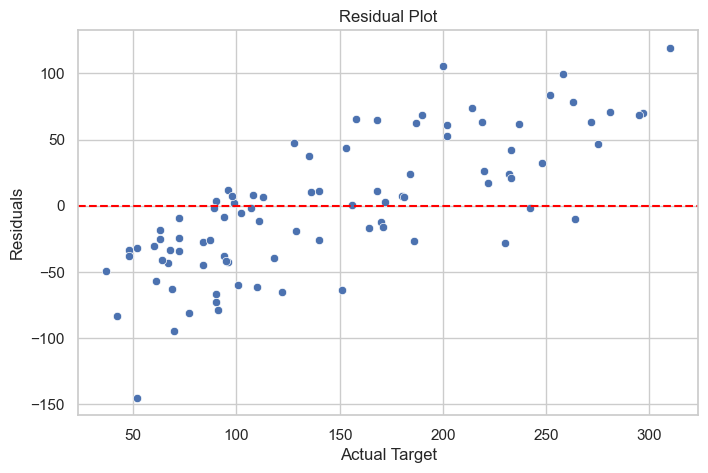

In [29]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_test, y=y_test - y_pred)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Actual Target")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

**Feature Importance Visualization**

In [30]:
feature_importance = best_model.named_steps['model'].get_feature_importance()
features = X_scaled_df.columns
importance_df = pd.DataFrame({"Feature": features, "Importance": feature_importance})
importance_df.sort_values(by="Importance", ascending=False, inplace=True)

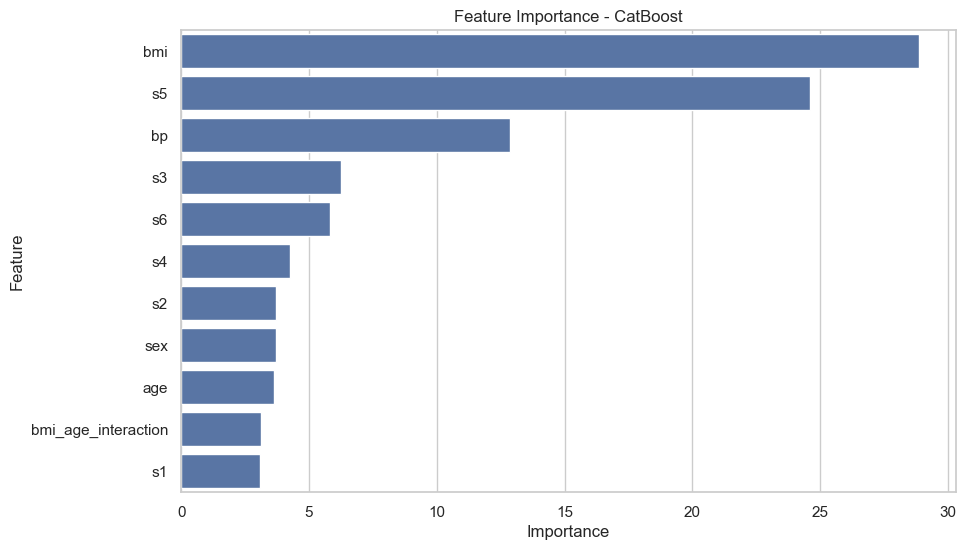

In [31]:
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Feature Importance - CatBoost")
plt.show()

**Model Explainability using SHAP**

In [32]:
explainer = shap.TreeExplainer(best_model.named_steps['model'])
shap_values = explainer.shap_values(X_test)

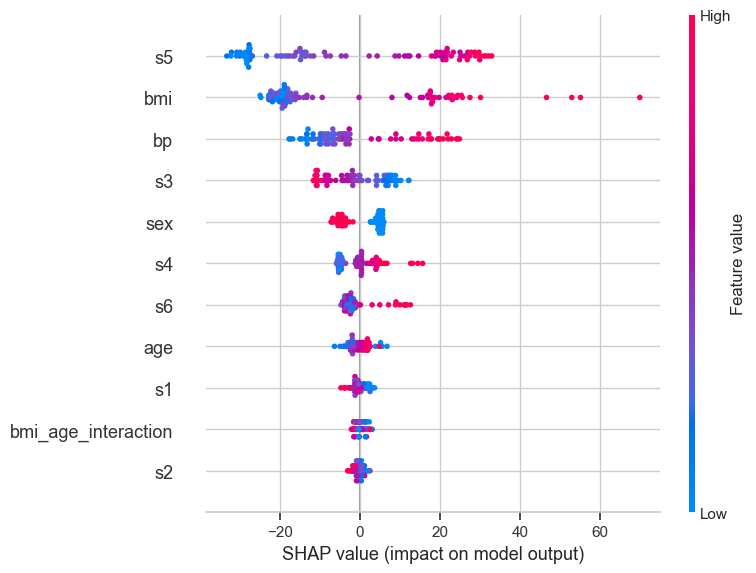

In [33]:
shap.summary_plot(shap_values, X_test, feature_names=X_scaled_df.columns)

**Saving the Model**

In [35]:
joblib.dump(best_model, "catboost_regressor_diabetes.pkl")
print("Model saved successfully!")

Model saved successfully!


## CatBoostRegressor Theory
CatBoost is a gradient boosting algorithm designed to handle categorical features efficiently using "Ordered Boosting".
It builds an ensemble of decision trees in a sequential manner, optimizing for a loss function (like RMSE for regression).

#### 1️ Algorithm Overview (Expanded)

* **CatBoost** is a type of **gradient boosting** algorithm.
* Gradient boosting works by **building multiple decision trees sequentially**, where each new tree tries to fix the errors (residuals) of the previous trees.
* CatBoost is **special because it handles categorical features natively**, without the need for one-hot encoding. It uses **“Ordered Boosting”** to reduce overfitting caused by data leakage during training.
* For regression problems, CatBoost optimizes a **loss function** such as **RMSE** (Root Mean Squared Error) or **MAE**.

**Key idea:** Instead of fitting all trees independently, each tree is trained on the **residual errors** of the previous ensemble.


#### 2️ Mathematical Intuition (Expanded)

Gradient boosting can be written as:

$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x) $$

Where:

* $(F_m(x))$ → prediction of the ensemble after the $(m^{th})$ tree
* $(F_{m-1}(x))$ → prediction from the previous $(m-1)$ trees
* $(h_m(x))$ → the new decision tree fitted to the **negative gradient** of the loss function
* $(\eta)$ → learning rate, which controls the contribution of the new tree

#### Step-by-step explanation:

1. Start with an initial prediction $(F_0(x))$ (usually the mean of the target for regression).
2. Compute the **residuals** (or gradients) of the loss function:

$$
r_i^{(m)} = - \frac{\partial L(y_i, F_{m-1}(x_i))}{\partial F_{m-1}(x_i)}
$$

3. Fit a **new tree** $(h_m(x))$ to these residuals.
4. Update the prediction:

$$
F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)
$$

5. Repeat steps 2–4 for a set number of iterations (trees).

* In CatBoost, **Ordered Boosting** ensures that the gradient calculation for a data point does not “peek” at its own target, which reduces overfitting.
* The final prediction is the sum of all tree contributions.


#### 3. When to Use:
- Regression tasks with numeric and categorical data
- Datasets with potential overfitting
- Scenarios needing robust default hyperparameters

#### 4. Advantages:
- Handles categorical data natively
- Low overfitting risk
- GPU support for large datasets
- High accuracy

#### 5. Disadvantages:
- Training can be slower than simpler models
- Hyperparameter tuning may still be required for best results
- Less interpretable than linear models

#### 6. Important Hyperparameters:
- learning_rate: Step size for boosting
- depth: Maximum tree depth
- iterations: Number of trees
- l2_leaf_reg: L2 regularization
- border_count: Number of splits for numerical features

#### 7. Practical Tuning Tips:
- Use 1000 iterations with early stopping for initial tests
- Tune learning_rate and depth for optimal performance
- Use built-in feature importance for model insights